## **PROMOTE Sprint - Day 1**
### Tutorial 3. Analysing CANARI Large-Ensemble with NEMO Cookbook

##### 13th July 2026

#### **Contact:**
Ollie Tooth (oliver.tooth@noc.ac.uk)

#### **Background:**
---

In this third hands-on tutorial, we will use the `NEMODataTree` object to analyse ocean & sea-ice outputs of the CANARI Large-Ensemble.

We will cover:

* Opening virtual `NEMODataTree` objects directly from Icechunk repositories using the `from_icechunk()` constructor.

* Exploring NEMO ocean & sea-ice variables stored in a `NEMODataTree`.

* Extracting hydrographic sections using `NEMODataTree.extract_zonal_section()`.

#### **3.1 Creating NEMODataTrees**
---

* Let's begin by importing the **NEMO Cookbook** Python library and the `NEMODataTree` class:

In [1]:
import os

import icechunk
from nemo_cookbook import NEMODataTree

##### **3.1.1 Virtual NEMODataTrees**

* Rather that having to merge *O*(100) - *O*(1000s) of netCDF files to create a `NEMODataTree` at the begining of every script, we can alternatively build a virtual `NEMODataTree`:

`Virtual NEMODataTree` -> lightweight, persistent map describing how to organise our netCDF files into a `NEMODataTree`.

* For the PROMOTE Analysis Sprint, we have created virtual `NEMODataTrees` for the following simulations:

    * **UKESM1-2-LL**: `/gws/ssde/j25b/terrafirma/otooth/repos/`

    * **CANARI-LE**: `/gws/ssde/j25b/canari/shared/large-ensemble/ocean/repos/`

* To access virtual `NEMODataTrees`, we can use the `.from_icechunk()` constructor:

---

`from_icechunk()`

* Creates a `NEMODataTree` from an Icechunk repository:

```
    <xarray.DataTree 'nemo'>
    Group: /
    ├── Group: /gridT
    ├── Group: /gridU
    ├── Group: /gridV
    ├── Group: /gridW
    └── Group: /gridF
```

where each grid node is stored as a virtual dataset in separate groups of a hierarchical Icechunk store.

---

* Here, we show how to construct a `NEMODataTree` from the 1/4° global ocean sea-ice component of the 40-member **CANARI-LE** using the available Icechunk repositories accessible via the `canari` group workspace.

* Let's start by exploring the available Icechunk repositories...

In [2]:
os.listdir("/gws/ssde/j25b/canari/shared/large-ensemble/ocean/repos/")

['domain', 'SSP370', 'HIST1', 'HIST2']

* Next, let's define a reusable function `open_virtual_NEMODataTree()` to open a virtual `NEMODataTree` given the `experiment` and `member` of a CANARI Large-Ensemble...

In [3]:
def open_virtual_NEMODataTree(
        experiment: str,
        member: str,
    ) -> NEMODataTree:
    # Authorise Icechunk to fetch virtual chunks from the original netCDF files on JASMIN canari group workspace:
    store_fpath = "/gws/ssde/j25b/canari/shared/large-ensemble"
    credentials = icechunk.credentials.containers_credentials({f"file://{store_fpath}/": icechunk.credentials.LocalFileSystemAccess})

    # Open Icechunk repository stored on JASMIN canari group workspace:
    repo_fpath = f"/gws/ssde/j25b/canari/shared/large-ensemble/ocean/repos/{experiment}/eORCA025_CANARI_LE_m{member}_monthly"
    repo = icechunk.Repository.open(storage=icechunk.local_filesystem_storage(repo_fpath),
                                    authorize_virtual_chunk_access=credentials
                                    )
    
    # Create virtual NEMODataTree from Icechunk repository:
    nemo = NEMODataTree.from_icechunk(repo=repo,
                                      branch="main",
                                      iperio=True,
                                      nftype="F",
                                      name=f"CANARI-LE {experiment} m{member}",
                                      )
            
    return nemo

In [4]:
nemo = open_virtual_NEMODataTree(experiment="SSP370", member="1")
nemo

  2026-07-12T12:29:57.850044Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324



<xarray.DataTree 'CANARI-LE SSP370 m1'>
Group: /
│   Attributes:
│       nftype:   F
│       iperio:   True
├── Group: /gridF
│       Dimensions:       (k: 75, j: 1207, i: 1442, time_counter: 1020)
│       Coordinates:
│         * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
│         * j             (j) float64 10kB 1.5 2.5 3.5 ... 1.206e+03 1.206e+03 1.208e+03
│         * i             (i) float64 12kB 1.5 2.5 3.5 ... 1.44e+03 1.442e+03 1.442e+03
│           glamf         (j, i) float32 7MB dask.array<chunksize=(1207, 1442), meta=np.ndarray>
│           gphif         (j, i) float32 7MB dask.array<chunksize=(1207, 1442), meta=np.ndarray>
│         * time_counter  (time_counter) object 8kB 2015-01-16 00:00:00 ... 2099-12-1...
│       Data variables:
│           fmask         (k, j, i) int8 131MB dask.array<chunksize=(25, 604, 721), meta=np.ndarray>
│           e1f           (j, i) float64 14MB dask.array<chunksize=(1207, 1442), meta=np.ndarray>
│           e2f           (j, i) float64 14MB dask.array<chunksize=(1207, 1442), meta=np.ndarray>
│           fmaskutil     (j, i) int8 2MB dask.array<chunksize=(1207, 1442), meta=np.ndarray>
│       Attributes:
│           nftype:   T
│           iperio:   True
├── Group: /gridT
│       Dimensions:              (time_counter: 1020, j: 1207, i: 1442, nvertex: 4,
│                                 k: 75, axis_nbounds: 2)
│       Coordinates:
│         * time_counter         (time_counter) object 8kB 2015-01-16 00:00:00 ... 20...
│         * j                    (j) int64 10kB 1 2 3 4 5 6 ... 1203 1204 1205 1206 1207
│         * i                    (i) int64 12kB 1 2 3 4 5 6 ... 1438 1439 1440 1441 1442
│           glamt                (j, i) float32 7MB dask.array<chunksize=(1207, 1442), meta=np.ndarray>
│           gphit                (j, i) float32 7MB dask.array<chunksize=(1207, 1442), meta=np.ndarray>
│         * k                    (k) int64 600B 1 2 3 4 5 6 7 8 ... 69 70 71 72 73 74 75
│           deptht               (k) float32 300B dask.array<chunksize=(75,), meta=np.ndarray>
│       Dimensions without coordinates: nvertex, axis_nbounds
│       Data variables: (12/17)
│           bounds_nav_lat       (time_counter, j, i, nvertex) float32 28GB dask.array<chunksize=(1, 604, 721, 2), meta=np.ndarray>
│           bounds_nav_lon       (time_counter, j, i, nvertex) float32 28GB dask.array<chunksize=(1, 604, 721, 2), meta=np.ndarray>
│           deptht_bounds        (time_counter, k, axis_nbounds) float32 612kB dask.array<chunksize=(1, 75, 2), meta=np.ndarray>
│           e3t                  (time_counter, k, j, i) float32 533GB dask.array<chunksize=(1, 19, 302, 361), meta=np.ndarray>
│           sohefldo             (time_counter, j, i) float32 7GB dask.array<chunksize=(1, 1207, 1442), meta=np.ndarray>
│           e2t                  (j, i) float64 14MB dask.array<chunksize=(1207, 1442), meta=np.ndarray>
│           ...                   ...
│           soicecov             (time_counter, j, i) float32 7GB dask.array<chunksize=(1, 1207, 1442), meta=np.ndarray>
│           tmask                (k, j, i) int8 131MB dask.array<chunksize=(25, 604, 721), meta=np.ndarray>
│           vosaline             (time_counter, k, j, i) float32 533GB dask.array<chunksize=(1, 19, 302, 361), meta=np.ndarray>
│           votemper             (time_counter, k, j, i) float32 533GB dask.array<chunksize=(1, 19, 302, 361), meta=np.ndarray>
│           time_counter_bounds  (time_counter, axis_nbounds) object 16kB dask.array<chunksize=(1, 2), meta=np.ndarray>
│           tmaskutil            (j, i) int8 2MB dask.array<chunksize=(1207, 1442), meta=np.ndarray>
│       Attributes: (12/37)
│           Conventions:            CF-1.10
│           contact:                 
│           grid:                   Native eORCA025 tripolar primarily 1/4 deg grid; ...
│           parent_time_units:      days since 1850-01-01
│           branch_time_in_parent:  2015
│           further_info_

#### **3.2 Navigating a NEMODataTree**
---

* Now we have created an example `NEMODataTree`, let's take a closer look at its contents and how to access NEMO model output variables.

* We'll start by looking at the nodes in our `NEMODataTree`:

In [5]:
nemo.groups

('/', '/gridF', '/gridT', '/gridV', '/gridW', '/gridU')

**Some Important Points:**

* A `NEMODataTree` does not have a `domain` node since grid scale factors and masks associated with each model domain are assigned to their respective grid nodes during pre-processing (e.g., horizontal grid scale factors `e1t` and `e2t` are stored in `gridT` etc.).

* During the construction of a `NEMODataTree`, the standard (`depth{p}`, `y`, `x`) dimensions of NEMO model outputs (where `p` is the grid point type) are transformed to NEMO grid indices (**i**, **j**, **k**). This has two important implications:

    * `xarray.Datasets` stored in each grid node share the same coordinate dimension names (`i`, `j`, `k`), but are staggered according to the location of variables on the NEMO model grid.

    * All grid indices use Fortran (1-based) indexing to be consistent with the original NEMO model code.

    | Grid Type    | Grid Indices                 |
    | -----------  | --------------------------   |
    | `T`          | $(i, j, k)$                    |
    | `U`          | $(i + \frac{1}{2}, j, k)$              |
    | `V`          | $(i, j + \frac{1}{2}, k)$              |
    | `W`          | $(i, j, k + \frac{1}{2})$              |
    | `F`          | $(i + \frac{1}{2}, j + \frac{1}{2}, k)$        |

---

* To see what this means in practice, we will consider the `gridT` and `gridU` nodes of the 2° `AGRIF_DEMO` `NEMODataTree` below:

In [6]:
nemo['gridT']

<xarray.DataTree 'gridT'>
Group: /gridT
    Dimensions:              (time_counter: 1020, j: 1207, i: 1442, nvertex: 4,
                              k: 75, axis_nbounds: 2)
    Coordinates:
      * time_counter         (time_counter) object 8kB 2015-01-16 00:00:00 ... 20...
      * j                    (j) int64 10kB 1 2 3 4 5 6 ... 1203 1204 1205 1206 1207
      * i                    (i) int64 12kB 1 2 3 4 5 6 ... 1438 1439 1440 1441 1442
        glamt                (j, i) float32 7MB dask.array<chunksize=(1207, 1442), meta=np.ndarray>
        gphit                (j, i) float32 7MB dask.array<chunksize=(1207, 1442), meta=np.ndarray>
      * k                    (k) int64 600B 1 2 3 4 5 6 7 8 ... 69 70 71 72 73 74 75
        deptht               (k) float32 300B dask.array<chunksize=(75,), meta=np.ndarray>
    Dimensions without coordinates: nvertex, axis_nbounds
    Data variables: (12/17)
        bounds_nav_lat       (time_counter, j, i, nvertex) float32 28GB dask.array<chunksize=(1, 604, 721, 2), meta=np.ndarray>
        bounds_nav_lon       (time_counter, j, i, nvertex) float32 28GB dask.array<chunksize=(1, 604, 721, 2), meta=np.ndarray>
        deptht_bounds        (time_counter, k, axis_nbounds) float32 612kB dask.array<chunksize=(1, 75, 2), meta=np.ndarray>
        e3t                  (time_counter, k, j, i) float32 533GB dask.array<chunksize=(1, 19, 302, 361), meta=np.ndarray>
        sohefldo             (time_counter, j, i) float32 7GB dask.array<chunksize=(1, 1207, 1442), meta=np.ndarray>
        e2t                  (j, i) float64 14MB dask.array<chunksize=(1207, 1442), meta=np.ndarray>
        ...                   ...
        soicecov             (time_counter, j, i) float32 7GB dask.array<chunksize=(1, 1207, 1442), meta=np.ndarray>
        tmask                (k, j, i) int8 131MB dask.array<chunksize=(25, 604, 721), meta=np.ndarray>
        vosaline             (time_counter, k, j, i) float32 533GB dask.array<chunksize=(1, 19, 302, 361), meta=np.ndarray>
        votemper             (time_counter, k, j, i) float32 533GB dask.array<chunksize=(1, 19, 302, 361), meta=np.ndarray>
        time_counter_bounds  (time_counter, axis_nbounds) object 16kB dask.array<chunksize=(1, 2), meta=np.ndarray>
        tmaskutil            (j, i) int8 2MB dask.array<chunksize=(1207, 1442), meta=np.ndarray>
    Attributes: (12/37)
        Conventions:            CF-1.10
        contact:                 
        grid:                   Native eORCA025 tripolar primarily 1/4 deg grid; ...
        parent_time_units:      days since 1850-01-01
        branch_time_in_parent:  2015
        further_info_url:       https://github.com/NCAS-CMS/canari-data
        ...                     ...
        parent_source_id:       CANARI-LE.NCAS.HadGEM3-GC31-MM.HIST2.r1i1p2f1
        variant_id:             r1i1p2f1
        realm:                  ocean
        external_variables:     areacello
        nftype:                 T
        iperio:                 True

In [7]:
nemo['gridU']

<xarray.DataTree 'gridU'>
Group: /gridU
    Dimensions:              (time_counter: 1020, j: 1207, i: 1442, nvertex: 4,
                              k: 75, axis_nbounds: 2)
    Coordinates:
      * time_counter         (time_counter) object 8kB 2015-01-16 00:00:00 ... 20...
      * j                    (j) int64 10kB 1 2 3 4 5 6 ... 1203 1204 1205 1206 1207
      * i                    (i) float64 12kB 1.5 2.5 3.5 ... 1.442e+03 1.442e+03
        glamu                (j, i) float32 7MB dask.array<chunksize=(1207, 1442), meta=np.ndarray>
        gphiu                (j, i) float32 7MB dask.array<chunksize=(1207, 1442), meta=np.ndarray>
      * k                    (k) int64 600B 1 2 3 4 5 6 7 8 ... 69 70 71 72 73 74 75
        depthu               (k) float32 300B dask.array<chunksize=(75,), meta=np.ndarray>
    Dimensions without coordinates: nvertex, axis_nbounds
    Data variables:
        bounds_nav_lon       (time_counter, j, i, nvertex) float32 28GB dask.array<chunksize=(1, 604, 721, 2), meta=np.ndarray>
        e2u                  (j, i) float64 14MB dask.array<chunksize=(1207, 1442), meta=np.ndarray>
        e3u                  (time_counter, k, j, i) float32 533GB dask.array<chunksize=(1, 19, 302, 361), meta=np.ndarray>
        e1u                  (j, i) float64 14MB dask.array<chunksize=(1207, 1442), meta=np.ndarray>
        sozotaux             (time_counter, j, i) float32 7GB dask.array<chunksize=(1, 1207, 1442), meta=np.ndarray>
        depthu_bounds        (time_counter, k, axis_nbounds) float32 612kB dask.array<chunksize=(1, 75, 2), meta=np.ndarray>
        time_counter_bounds  (time_counter, axis_nbounds) object 16kB dask.array<chunksize=(1, 2), meta=np.ndarray>
        umask                (k, j, i) int8 131MB dask.array<chunksize=(25, 604, 721), meta=np.ndarray>
        bounds_nav_lat       (time_counter, j, i, nvertex) float32 28GB dask.array<chunksize=(1, 604, 721, 2), meta=np.ndarray>
        vozocrtx             (time_counter, k, j, i) float32 533GB dask.array<chunksize=(1, 19, 302, 361), meta=np.ndarray>
        umaskutil            (j, i) int8 2MB dask.array<chunksize=(1207, 1442), meta=np.ndarray>
    Attributes: (12/37)
        Conventions:            CF-1.10
        experiment:             SSP3-7.0
        variant_id:             r1i1p2f1
        institution:            NCAS
        branch_method:          continuation of parent CANARI LE HIST2 run
        branch_time_in_parent:  2015
        ...                     ...
        realization_index:      1
        further_info_url:       https://github.com/NCAS-CMS/canari-data
        forcing_index:          1
        external_variables:     areacello
        nftype:                 T
        iperio:                 True

* Above, we have seen how to access the nodes in an `NEMODataTree` using a dictionary-like syntax.

* We can also extend this to include output variables stored in given grid node as follows...

* To access an **unmasked** variable (i.e., unchanged from the original model output files) as an `xarray.DataArray`:

In [8]:
nemo['gridT']['votemper']

<xarray.DataArray 'votemper' (time_counter: 1020, k: 75, j: 1207, i: 1442)> Size: 533GB
dask.array<open_dataset-votemper, shape=(1020, 75, 1207, 1442), dtype=float32, chunksize=(1, 19, 302, 361), chunktype=numpy.ndarray>
Coordinates:
  * time_counter  (time_counter) object 8kB 2015-01-16 00:00:00 ... 2099-12-1...
  * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
    deptht        (k) float32 300B dask.array<chunksize=(75,), meta=np.ndarray>
  * j             (j) int64 10kB 1 2 3 4 5 6 7 ... 1202 1203 1204 1205 1206 1207
  * i             (i) int64 12kB 1 2 3 4 5 6 7 ... 1437 1438 1439 1440 1441 1442
    glamt         (j, i) float32 7MB dask.array<chunksize=(1207, 1442), meta=np.ndarray>
    gphit         (j, i) float32 7MB dask.array<chunksize=(1207, 1442), meta=np.ndarray>
Attributes:
    standard_name:       sea_water_potential_temperature
    long_name:           Sea Water Potential Temperature
    units:               degree_C
    online_operation:    average
    interval_operation:  1 month
    interval_write:      1 month
    cell_measures:       area: areacello
    cell_methods:        time_counter: mean

* To access a **unmasked** variable as a `NEMODataArray` (i.e.,  NEMO grid-aware extension of `xarray.DataArray`), we can instead provide a direct path to the variable:

In [9]:
nemo["gridT/votemper"]

<NEMODataTree 'CANARI-LE SSP370 m1'>
  <NEMODataArray 'votemper' (Domain: '.', Grid: 'gridT', Grid Type: 'T')>

<xarray.DataArray 'votemper' (time_counter: 1020, k: 75, j: 1207, i: 1442)> Size: 533GB
dask.array<open_dataset-votemper, shape=(1020, 75, 1207, 1442), dtype=float32, chunksize=(1, 19, 302, 361), chunktype=numpy.ndarray>
Coordinates:
  * time_counter  (time_counter) object 8kB 2015-01-16 00:00:00 ... 2099-12-1...
  * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
    deptht        (k) float32 300B dask.array<chunksize=(75,), meta=np.ndarray>
  * j             (j) int64 10kB 1 2 3 4 5 6 7 ... 1202 1203 1204 1205 1206 1207
  * i             (i) int64 12kB 1 2 3 4 5 6 7 ... 1437 1438 1439 1440 1441 1442
    glamt         (j, i) float32 7MB dask.array<chunksize=(1207, 1442), meta=np.ndarray>
    gphit         (j, i) float32 7MB dask.array<chunksize=(1207, 1442), meta=np.ndarray>
Attributes:
    standard_name:       sea_water_potential_temperature
    long_name:           Sea Water Potential Temperature
    units:               degree_C
    online_operation:    average
    interval_operation:  1 month
    interval_write:      1 month
    cell_measures:       area: areacello
    cell_methods:        time_counter: mean

* To access a **masked** (i.e., the appropriate land-sea mask is applied automatically) variable as an `NEMODataArray`, we can instead provide a direct path to the variable:

In [10]:
nemo["gridT/votemper"].masked

<NEMODataTree 'CANARI-LE SSP370 m1'>
  <NEMODataArray 'votemper' (Domain: '.', Grid: 'gridT', Grid Type: 'T')>

<xarray.DataArray 'votemper' (time_counter: 1020, k: 75, j: 1207, i: 1442)> Size: 533GB
dask.array<where, shape=(1020, 75, 1207, 1442), dtype=float32, chunksize=(1, 19, 302, 361), chunktype=numpy.ndarray>
Coordinates:
  * time_counter  (time_counter) object 8kB 2015-01-16 00:00:00 ... 2099-12-1...
  * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
    deptht        (k) float32 300B dask.array<chunksize=(75,), meta=np.ndarray>
  * j             (j) int64 10kB 1 2 3 4 5 6 7 ... 1202 1203 1204 1205 1206 1207
  * i             (i) int64 12kB 1 2 3 4 5 6 7 ... 1437 1438 1439 1440 1441 1442
    glamt         (j, i) float32 7MB dask.array<chunksize=(1207, 1442), meta=np.ndarray>
    gphit         (j, i) float32 7MB dask.array<chunksize=(1207, 1442), meta=np.ndarray>
Attributes:
    standard_name:       sea_water_potential_temperature
    long_name:           Sea Water Potential Temperature
    units:               degree_C
    online_operation:    average
    interval_operation:  1 month
    interval_write:      1 month
    cell_measures:       area: areacello
    cell_methods:        time_counter: mean

#### **3.3 Extracting Hydrographic Sections from a NEMODataTree**
---

* Next, let's extract an approximately zonal section at the latitude of the North Atlantic Changes (NOAC) 47°N array from our NEMODataTree.

* The resulting hydrographic section will be defined on the NEMO model V-grid at the constant j-coordinate whose average latitude is closest to 47°N.

* Notice that we need to provide the names of the zonal vector variables (e.g., `u_vars=["sozotaux"]`) and any scalar variables (e.g., `scalar_vars=['votemper', 'vosaline']`) to be linearly interpolated onto the V-grid.

In [11]:
# Extract the NOAC 47N array from our CANARI-LE NEMODataTree:
ds_noac = nemo.extract_zonal_section(lat=47.0,
                                     lon_min=-53.65,
                                     lon_max=-0.61,
                                     u_vars=["sozotaux"],
                                     scalar_vars=["votemper", "vosaline"],
                                     dom="."
                                     )

ds_noac

<xarray.Dataset> Size: 392MB
Dimensions:              (time_counter: 1020, bdy: 208, nvertex: 4, k: 75,
                          axis_nbounds: 2)
Coordinates:
  * time_counter         (time_counter) object 8kB 2015-01-16 00:00:00 ... 20...
  * i                    (bdy) int64 2kB 938 939 940 941 ... 1142 1143 1144 1145
    gphib                (bdy) float32 832B dask.array<chunksize=(208,), meta=np.ndarray>
    glamb                (bdy) float32 832B dask.array<chunksize=(208,), meta=np.ndarray>
  * k                    (k) int64 600B 1 2 3 4 5 6 7 8 ... 69 70 71 72 73 74 75
    depthb               (k) float32 300B dask.array<chunksize=(75,), meta=np.ndarray>
    j                    float64 8B 899.5
Dimensions without coordinates: bdy, nvertex, axis_nbounds
Data variables: (12/16)
    bounds_nav_lat       (time_counter, bdy, nvertex) float32 3MB dask.array<chunksize=(1, 208, 2), meta=np.ndarray>
    e1b                  (bdy) float64 2kB dask.array<chunksize=(208,), meta=np.ndarray>
    e3b                  (time_counter, k, bdy) float32 64MB dask.array<chunksize=(1, 19, 146), meta=np.ndarray>
    e2b                  (bdy) float64 2kB dask.array<chunksize=(208,), meta=np.ndarray>
    bounds_nav_lon       (time_counter, bdy, nvertex) float32 3MB dask.array<chunksize=(1, 208, 2), meta=np.ndarray>
    depthv_bounds        (time_counter, k, axis_nbounds) float32 612kB dask.array<chunksize=(1, 75, 2), meta=np.ndarray>
    ...                   ...
    bmaskutil            (bdy) int8 208B dask.array<chunksize=(208,), meta=np.ndarray>
    votemper             (time_counter, k, bdy) float64 127MB dask.array<chunksize=(1, 19, 146), meta=np.ndarray>
    vosaline             (time_counter, k, bdy) float64 127MB dask.array<chunksize=(1, 19, 146), meta=np.ndarray>
    sozotaux             (time_counter, bdy) float64 2MB dask.array<chunksize=(1, 208), meta=np.ndarray>
    i_bdy                (bdy) int64 2kB 938 939 940 941 ... 1142 1143 1144 1145
    j_bdy                (bdy) float64 2kB 899.5 899.5 899.5 ... 899.5 899.5
Attributes: (12/35)
    Conventions:            CF-1.10
    parent_variant_label:   r1i1p2f1
    forcing_index:          1
    parent_activity_id:      
    branch_time_in_child:   2015
    contact:                 
    ...                     ...
    grid:                   Native eORCA025 tripolar primarily 1/4 deg grid; ...
    realization_index:      1
    variant_id:             r1i1p2f1
    frequency:               
    activity_id:            CANARI-LE
    external_variables:     areacello

**Taking a closer look at our hydrographic section dataset, we can see it is structured analogously to a NEMO model grid node within our `NEMODataTree`:**

* Inherited NEMO Grid Dimension: `k`

* New Along-Boundary Grid Dimension: `bdy`, such that `i_bdy(bdy)`, `j_bdy(bdy)`

* Geographical Coordinates: `glamb` (longitude), `gphib` (latitude).

* Horizontal Grid Scale Factors: `e1b`, `e2b`

* Vertical Grid Scale Factors: `e3b`

* Land-Sea Masks: `bmask`, `bmaskutil`

### **Visualising properties along the NOAC 47°N array**

---

* Next, let's plot the time-mean conservative temperature along the NOAC 47°N array:

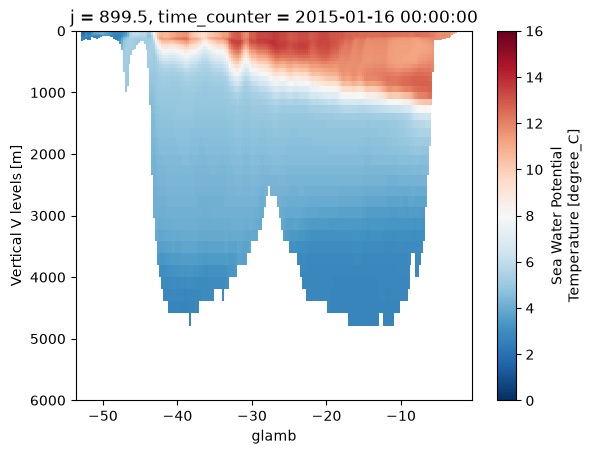

In [12]:
(ds_noac["votemper"]
 .isel(time_counter=0)
 .plot(x='glamb', y='depthb', yincrease=False, cmap='RdBu_r', vmin=0, vmax=16)
 )

### **Calculating Meridional Overturning Stream Function along the NOAC 47°N array**

---

* Finally, let's calculate the meridional overturning stream function in depth coordinates along the NOAC 47°N array.

* To ensure consistency with NOAC 47°N observational estimates, we first introduce a uniform compensation velocity $v_{c}(t)$ such that the net volume transport across the zonal section is zero at each output time. The compensation is applied uniformly over the section to obtain the adjusted velocity field $v^{*}(t, k, bdy)$.

$$v^{*}(t, k, \mathrm{bdy}) = v(t, k, \mathrm{bdy}) + v_c(t)$$

where

$$v_c(t) = -\frac{V(t)}{\displaystyle \sum_{\mathrm{bdy}} \sum_k e_{1b}\, e_{3b}}$$

and $V(t)$ is the net volume transport across the section, and $e_{1b}$ and $e_{3b}$ are the zonal and vertical grid scale factors defined along the section, respectively.

In [13]:
# Define grid cell face area variables (m2):
ds_noac['area'] = ds_noac['e3b'] * ds_noac['e1b']
ds_noac['area'].name = 'area'

# Calculate volume transport = seawater velocity x grid cell face area [m3/s]:
ds_noac['vto'] = ds_noac['vomecrty'] * ds_noac['area']

# Calculate compensation volume transport = - net volume transport across the NOAC 47°N array [m3/s]:
ds_noac['vto_comp'] = -ds_noac['vto'].sum(dim=['k', 'bdy'])

# Calculate uniform compensation velocity = - net volume transport / total grid cell face area [m/s]:
ds_noac['vo_comp'] = ds_noac['bmask'] * (ds_noac['vto_comp'] / ds_noac['area'].sum(dim=['k', 'bdy']))

# Calculate adjusted seawater velocity [m/s]:
ds_noac['vo_adj'] = ds_noac['vomecrty'] + ds_noac['vo_comp']

# Calculate adjusted volume transport [m3/s]:
ds_noac['vto_adj'] = ds_noac['vo_adj'] * ds_noac['area']

ds_noac

<xarray.Dataset> Size: 1GB
Dimensions:              (time_counter: 1020, bdy: 208, nvertex: 4, k: 75,
                          axis_nbounds: 2)
Coordinates:
  * time_counter         (time_counter) object 8kB 2015-01-16 00:00:00 ... 20...
  * i                    (bdy) int64 2kB 938 939 940 941 ... 1142 1143 1144 1145
    gphib                (bdy) float32 832B dask.array<chunksize=(208,), meta=np.ndarray>
    glamb                (bdy) float32 832B dask.array<chunksize=(208,), meta=np.ndarray>
  * k                    (k) int64 600B 1 2 3 4 5 6 7 8 ... 69 70 71 72 73 74 75
    depthb               (k) float32 300B dask.array<chunksize=(75,), meta=np.ndarray>
    j                    float64 8B 899.5
Dimensions without coordinates: bdy, nvertex, axis_nbounds
Data variables: (12/22)
    bounds_nav_lat       (time_counter, bdy, nvertex) float32 3MB dask.array<chunksize=(1, 208, 2), meta=np.ndarray>
    e1b                  (bdy) float64 2kB dask.array<chunksize=(208,), meta=np.ndarray>
    e3b                  (time_counter, k, bdy) float32 64MB dask.array<chunksize=(1, 19, 146), meta=np.ndarray>
    e2b                  (bdy) float64 2kB dask.array<chunksize=(208,), meta=np.ndarray>
    bounds_nav_lon       (time_counter, bdy, nvertex) float32 3MB dask.array<chunksize=(1, 208, 2), meta=np.ndarray>
    depthv_bounds        (time_counter, k, axis_nbounds) float32 612kB dask.array<chunksize=(1, 75, 2), meta=np.ndarray>
    ...                   ...
    area                 (time_counter, k, bdy) float64 127MB dask.array<chunksize=(1, 19, 146), meta=np.ndarray>
    vto                  (time_counter, k, bdy) float64 127MB dask.array<chunksize=(1, 19, 146), meta=np.ndarray>
    vto_comp             (time_counter) float64 8kB dask.array<chunksize=(1,), meta=np.ndarray>
    vo_comp              (k, bdy, time_counter) float64 127MB dask.array<chunksize=(25, 208, 1), meta=np.ndarray>
    vo_adj               (time_counter, k, bdy) float64 127MB dask.array<chunksize=(1, 19, 146), meta=np.ndarray>
    vto_adj              (time_counter, k, bdy) float64 127MB dask.array<chunksize=(1, 19, 146), meta=np.ndarray>
Attributes: (12/35)
    Conventions:            CF-1.10
    parent_variant_label:   r1i1p2f1
    forcing_index:          1
    parent_activity_id:      
    branch_time_in_child:   2015
    contact:                 
    ...                     ...
    grid:                   Native eORCA025 tripolar primarily 1/4 deg grid; ...
    realization_index:      1
    variant_id:             r1i1p2f1
    frequency:               
    activity_id:            CANARI-LE
    external_variables:     areacello

* Next, let's calculate the vertical overturning stream function by approximating the vertical coordinate $k$ coordinates for depth coordinates.

* Note that both the vertical grid cell thickness and depth of each grid cell are in-fact evolving through time when using `zps` vertical coordinates, however, we will choose to neglect these small variations for simplicity here.

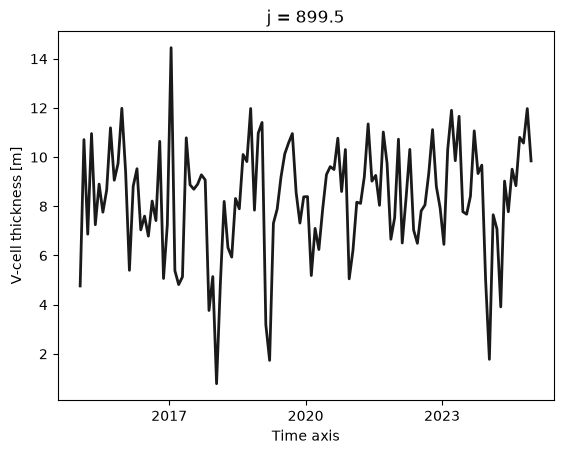

In [14]:
# Calculate meridional overturning circulation (MOC) streamfunction [Sv]:
ds_noac['moc_k'] = 1E-6 * ds_noac['vto_adj'].sum(dim=['bdy']).cumsum(dim='k')

# Plot the maximum MOC streamfunction over the first 10 years of the simulation:
(ds_noac['moc_k']
 .isel(time_counter=slice(None, 120))
 .max(dim="k")
 .plot(linewidth=2, color='0.1')
 )